In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv('../data/Fraudulent_E-Commerce_Transaction_Data.csv')

In [4]:
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")

print(df.head())

print("\nColumn names:")

print(df.columns.tolist())

print("\nData types:")

print(df.dtypes)

Dataset shape: (1472952, 16)

First 5 rows:
                         Transaction ID                           Customer ID  \
0  15d2e414-8735-46fc-9e02-80b472b2580f  d1b87f62-51b2-493b-ad6a-77e0fe13e785   
1  0bfee1a0-6d5e-40da-a446-d04e73b1b177  37de64d5-e901-4a56-9ea0-af0c24c069cf   
2  e588eef4-b754-468e-9d90-d0e0abfc1af0  1bac88d6-4b22-409a-a06b-425119c57225   
3  4de46e52-60c3-49d9-be39-636681009789  2357c76e-9253-4ceb-b44e-ef4b71cb7d4d   
4  074a76de-fe2d-443e-a00c-f044cdb68e21  45071bc5-9588-43ea-8093-023caec8ea1c   

   Transaction Amount     Transaction Date Payment Method Product Category  \
0               58.09  2024-02-20 05:58:41  bank transfer      electronics   
1              389.96  2024-02-25 08:09:45     debit card      electronics   
2              134.19  2024-03-18 03:42:55         PayPal    home & garden   
3              226.17  2024-03-16 20:41:31  bank transfer         clothing   
4              121.53  2024-01-15 05:08:17  bank transfer         clothing   



In [5]:
print("Missing values per column:")

print(df.isnull().sum())

print("\nPercentage of missing values:")

print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
Transaction ID        0
Customer ID           0
Transaction Amount    0
Transaction Date      0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Customer Location     0
Device Used           0
IP Address            0
Shipping Address      0
Billing Address       0
Is Fraudulent         0
Account Age Days      0
Transaction Hour      0
dtype: int64

Percentage of missing values:
Transaction ID        0.0
Customer ID           0.0
Transaction Amount    0.0
Transaction Date      0.0
Payment Method        0.0
Product Category      0.0
Quantity              0.0
Customer Age          0.0
Customer Location     0.0
Device Used           0.0
IP Address            0.0
Shipping Address      0.0
Billing Address       0.0
Is Fraudulent         0.0
Account Age Days      0.0
Transaction Hour      0.0
dtype: float64


In [9]:
print("Statistical summary:")
print(df.describe())

Statistical summary:
       Transaction Amount      Quantity  Customer Age  Is Fraudulent  \
count        1.472952e+06  1.472952e+06  1.472952e+06   1.472952e+06   
mean         2.267683e+02  3.000230e+00  3.451208e+01   5.012926e-02   
std          2.703951e+02  1.414736e+00  1.000313e+01   2.182117e-01   
min          1.000000e+01  1.000000e+00 -1.600000e+01   0.000000e+00   
25%          6.861000e+01  2.000000e+00  2.800000e+01   0.000000e+00   
50%          1.517600e+02  3.000000e+00  3.500000e+01   0.000000e+00   
75%          2.960500e+02  4.000000e+00  4.100000e+01   0.000000e+00   
max          1.270175e+04  5.000000e+00  8.600000e+01   1.000000e+00   

       Account Age Days  Transaction Hour  
count      1.472952e+06      1.472952e+06  
mean       1.796464e+02      1.128696e+01  
std        1.068642e+02      6.975995e+00  
min        1.000000e+00      0.000000e+00  
25%        8.600000e+01      5.000000e+00  
50%        1.790000e+02      1.100000e+01  
75%        2.720000e+0

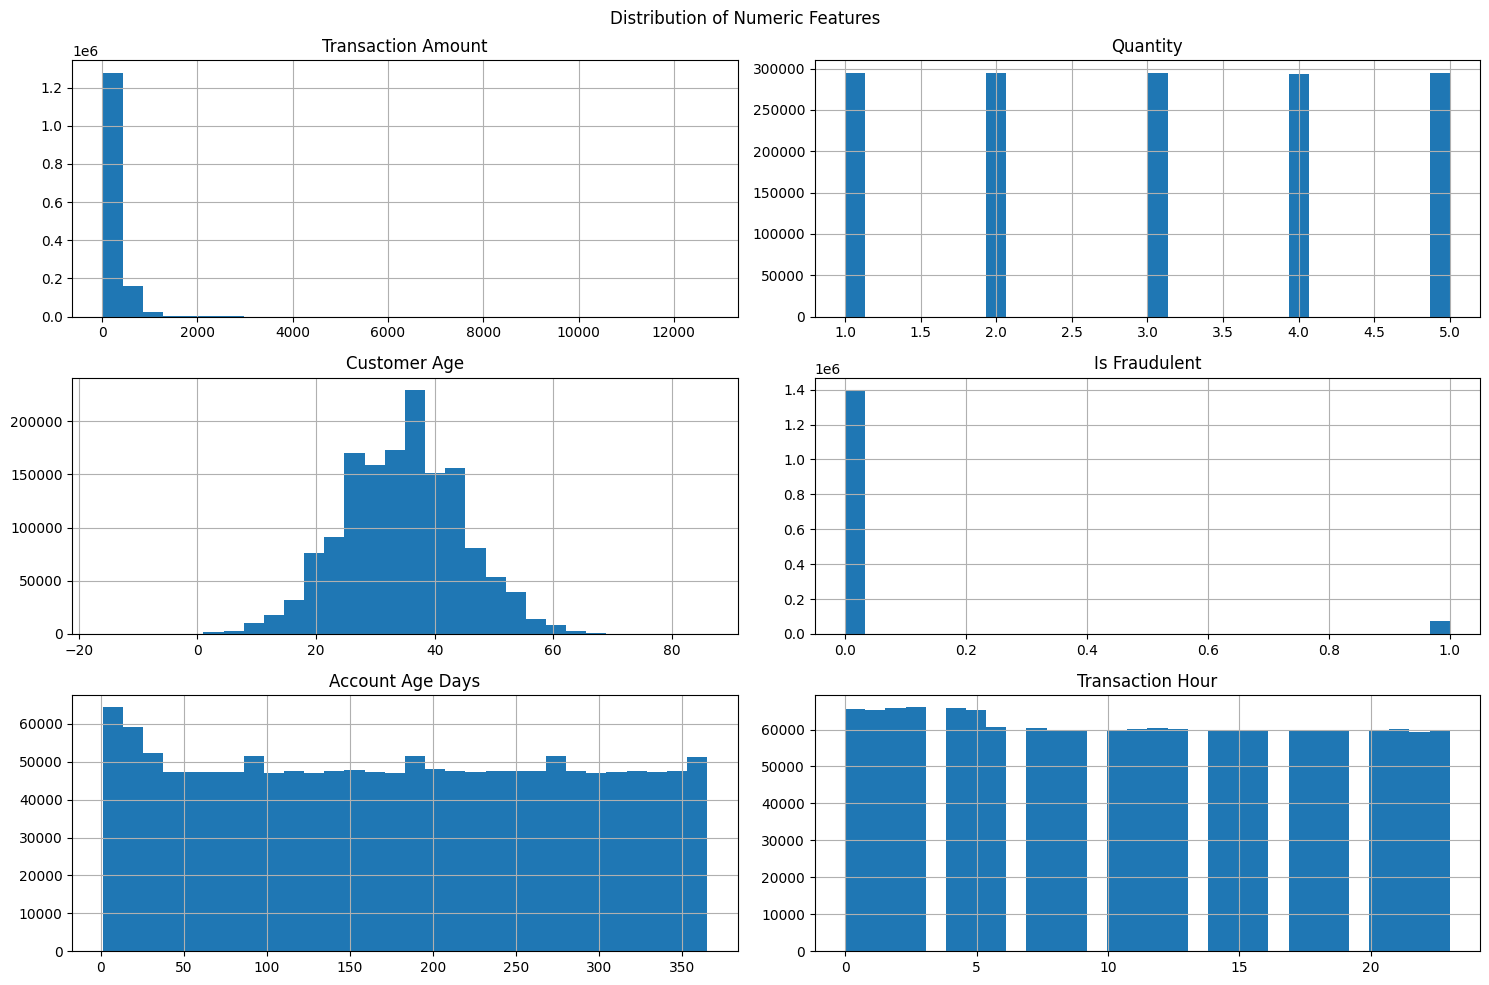

In [11]:
df.select_dtypes(include=[np.number]).hist(figsize=(15,10),bins=30)
plt.suptitle('Distribution of Numeric Features')
plt.tight_layout()
plt.show()

Class distribution:
Is Fraudulent
0    1399114
1      73838
Name: count, dtype: int64

Percentage:
Is Fraudulent
0    94.987074
1     5.012926
Name: proportion, dtype: float64


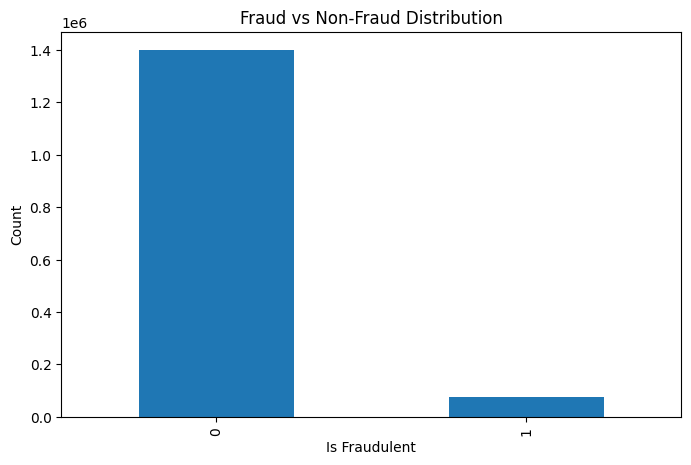

In [16]:
fraud_column = 'Is Fraudulent'

if fraud_column in df.columns:
    print("Class distribution:")
    print(df[fraud_column].value_counts())
    print("\nPercentage:")
    print(df[fraud_column].value_counts(normalize=True) * 100)
    
    plt.figure(figsize=(8, 5))
    df[fraud_column].value_counts().plot(kind='bar')
    plt.title('Fraud vs Non-Fraud Distribution')
    plt.xlabel(fraud_column)
    plt.ylabel('Count')
    plt.show()
else:
    print(f"Column '{fraud_column}' not found in dataset")
    print("Available columns:", df.columns.tolist())

In [18]:
print("=== DETAILED DATA ANALYSIS ===\n")
print("1. Data Types:")
print(df.dtypes)
print("\n" + "="*50 + "\n")

print("2. Missing Values Detail:")
missing_info = pd.DataFrame({
'Column': df.columns,
'Missing_Count': df.isnull().sum(),
'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)})
print(missing_info)
print("\n" + "="*50 + "\n")

print("3. Categorical Columns:")
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Found {len(categorical_cols)} categorical columns: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col} - Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head())

=== DETAILED DATA ANALYSIS ===

1. Data Types:
Transaction ID         object
Customer ID            object
Transaction Amount    float64
Transaction Date       object
Payment Method         object
Product Category       object
Quantity                int64
Customer Age            int64
Customer Location      object
Device Used            object
IP Address             object
Shipping Address       object
Billing Address        object
Is Fraudulent           int64
Account Age Days        int64
Transaction Hour        int64
dtype: object


2. Missing Values Detail:
                                Column  Missing_Count  Missing_Percentage
Transaction ID          Transaction ID              0                 0.0
Customer ID                Customer ID              0                 0.0
Transaction Amount  Transaction Amount              0                 0.0
Transaction Date      Transaction Date              0                 0.0
Payment Method          Payment Method              0        

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Fraudulent_E-Commerce_Transaction_Data.csv')

print("=== NUMERIC COLUMNS STATISTICS ===\n")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Found {len(numeric_cols)} numeric columns: {numeric_cols}\n")

for col in numeric_cols:
    print(f"{col}:")
    print(f" Min: {df[col].min()}")
    print(f" Max: {df[col].max()}")
    print(f" Mean: {df[col].mean():.2f}")
    print(f" Median: {df[col].median():.2f}")
    print(f" Std Dev: {df[col].std():.2f}")
    print()

=== NUMERIC COLUMNS STATISTICS ===

Found 6 numeric columns: ['Transaction Amount', 'Quantity', 'Customer Age', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour']

Transaction Amount:
 Min: 10.0
 Max: 12701.75
 Mean: 226.77
 Median: 151.76
 Std Dev: 270.40

Quantity:
 Min: 1
 Max: 5
 Mean: 3.00
 Median: 3.00
 Std Dev: 1.41

Customer Age:
 Min: -16
 Max: 86
 Mean: 34.51
 Median: 35.00
 Std Dev: 10.00

Is Fraudulent:
 Min: 0
 Max: 1
 Mean: 0.05
 Median: 0.00
 Std Dev: 0.22

Account Age Days:
 Min: 1
 Max: 365
 Mean: 179.65
 Median: 179.00
 Std Dev: 106.86

Transaction Hour:
 Min: 0
 Max: 23
 Mean: 11.29
 Median: 11.00
 Std Dev: 6.98



=== CORRELATION ANALYSIS ===



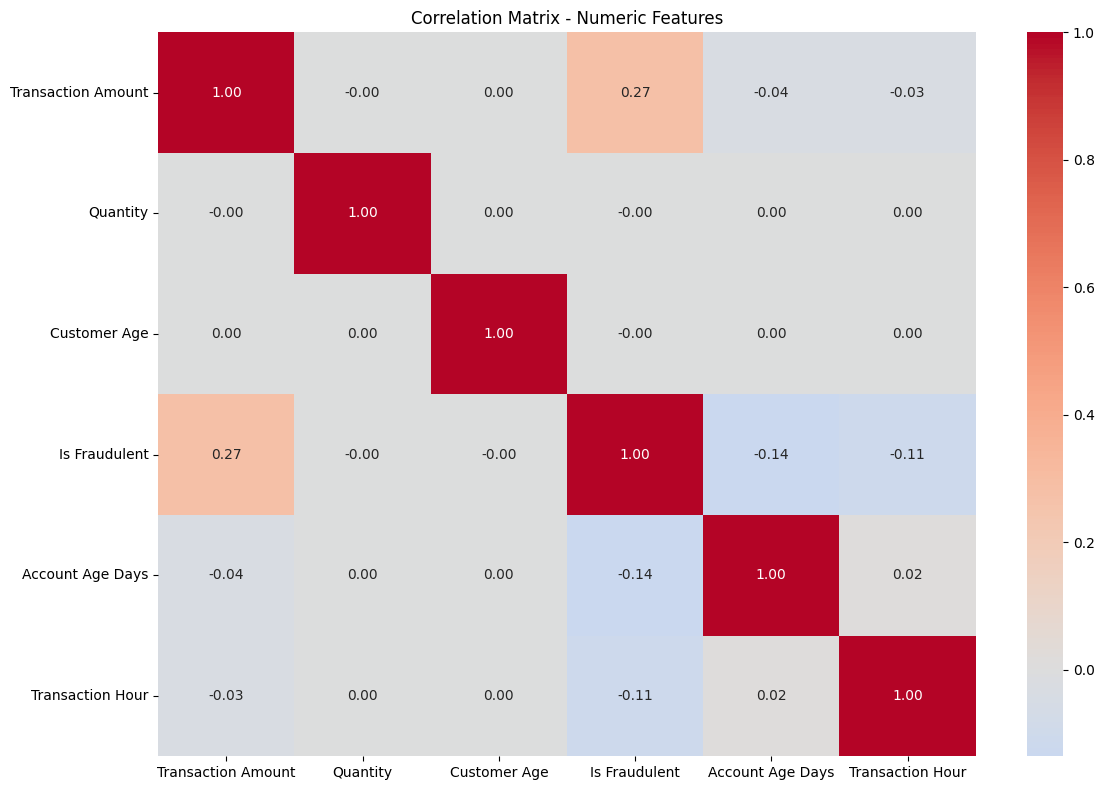


Correlation with target (Is Fraudulent):
Is Fraudulent         1.000000
Transaction Amount    0.272766
Quantity             -0.001027
Customer Age         -0.001129
Transaction Hour     -0.112821
Account Age Days     -0.136188
Name: Is Fraudulent, dtype: float64


In [10]:
print("=== CORRELATION ANALYSIS ===\n")

numeric_df = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

print("\nCorrelation with target (Is Fraudulent):")
if 'Is Fraudulent' in numeric_df.columns:
    print(numeric_df.corr()['Is Fraudulent'].sort_values(ascending=False))

EDA Summary - Dataset Overview

Key Findings

Dataset Size:
- Total rows: {len(df)}
- Total columns: {len(df.columns)}

Class Distribution:
- Fraud vs Non-Fraud imbalance: Perlu handle di preprocessing

Missing Values:
- Cek output cell 8 untuk detail missing values per column

Data Types:
- Numeric columns: {list numeric columns}
- Categorical columns: {list categorical columns}

Feature Insights:
- Top correlated features dengan fraud_label: Lihat output cell 10

Next Steps
1. Handle missing values (dropna atau fillna)
2. Encode categorical features
3. Normalize numeric features
4. Train machine learning model
5. Evaluate dan compare models